In [55]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from torchsummary import summary

In [56]:
df = pd.read_csv('/content/drive/MyDrive/wine.csv')
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [57]:
X = df.drop('Alcohol', axis=1)
y = df['Alcohol']

In [58]:
# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [59]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # 회귀를 위해 float32 및 모양 변경

X_test = torch.tensor(X_test, dtype=torch.float32)

# 요청하신 스타일대로 y_test를 변환 (회귀이므로 dtype은 float32로 유지해야 에러가 안 납니다)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

In [60]:
# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [61]:
class WineRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(WineRegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # 마지막 출력 노드는 1개 (수치 예측)
        )

    def forward(self, x):
        return self.net(x)

In [62]:
model = WineRegressionModel(X_train.shape[1])
summary(model, input_size=(X_train.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             896
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
Total params: 3,009
Trainable params: 3,009
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [63]:
criterion = nn.MSELoss() # 분류용 CrossEntropy 대신 회귀용 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [70]:
# Variables to store loss (회귀에서는 정확도 대신 MSE/MAE 손실을 기록합니다)
train_losses = []
test_losses = [] # test_accuracies 대신 test_losses 사용

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # [수정] 회귀용 Loss 계산: labels를 float 타입으로 바꾸고 모양을 (batch, 1)로 맞춥니다.
        loss = criterion(outputs, labels.float().view(-1, 1))

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 에포크당 평균 학습 손실 저장
    train_losses.append(running_loss / len(train_dataloader))

    # Evaluate on test data (평가 단계)
    model.eval()
    test_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)

            # [수정] 정확도 계산 대신 테스트 손실(오차)을 계산합니다.
            loss = criterion(outputs, labels.float().view(-1, 1))
            test_running_loss += loss.item()

    # 에포크당 평균 테스트 손실 저장
    avg_test_loss = test_running_loss / len(test_dataloader)
    test_losses.append(avg_test_loss)

    # [수정] Accuracy 대신 Loss 값을 출력하여 모델이 얼마나 정답에 가까워지는지 확인합니다.
    print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {avg_test_loss:.4f}")

print("Training complete.")

Epoch 1/20, Train Loss: 1.5993, Test Loss: 3.3558
Epoch 2/20, Train Loss: 1.5500, Test Loss: 3.2959
Epoch 3/20, Train Loss: 1.6094, Test Loss: 3.2182
Epoch 4/20, Train Loss: 1.4659, Test Loss: 3.1493
Epoch 5/20, Train Loss: 1.4785, Test Loss: 3.0909
Epoch 6/20, Train Loss: 1.4484, Test Loss: 3.0759
Epoch 7/20, Train Loss: 1.4816, Test Loss: 3.0583
Epoch 8/20, Train Loss: 1.5636, Test Loss: 3.0746
Epoch 9/20, Train Loss: 1.3996, Test Loss: 2.9522
Epoch 10/20, Train Loss: 1.5462, Test Loss: 2.9199
Epoch 11/20, Train Loss: 1.4582, Test Loss: 2.8879
Epoch 12/20, Train Loss: 1.4753, Test Loss: 2.9514
Epoch 13/20, Train Loss: 1.3607, Test Loss: 2.9516
Epoch 14/20, Train Loss: 1.3572, Test Loss: 2.9683
Epoch 15/20, Train Loss: 1.4147, Test Loss: 2.9495
Epoch 16/20, Train Loss: 1.3519, Test Loss: 2.8598
Epoch 17/20, Train Loss: 1.3702, Test Loss: 2.7809
Epoch 18/20, Train Loss: 1.4738, Test Loss: 2.6657
Epoch 19/20, Train Loss: 1.3115, Test Loss: 2.6972
Epoch 20/20, Train Loss: 1.3564, Test Lo


[최종 결과]
평균 절대 오차 (MAE): 1.1747
결정 계수 (R2 Score): -2.0619


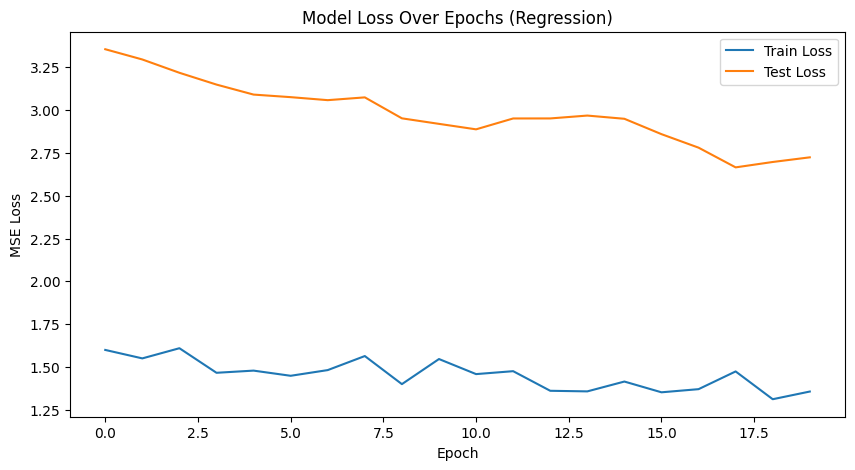

In [72]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    # sklearn 지표를 위해 numpy로 변환
    mae = mean_absolute_error(y_test.numpy(), y_pred.numpy())
    r2 = r2_score(y_test.numpy(), y_pred.numpy())

print(f'\n[최종 결과]')
print(f'평균 절대 오차 (MAE): {mae:.4f}')
print(f'결정 계수 (R2 Score): {r2:.4f}')

# 시각화: Loss 그래프
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Model Loss Over Epochs (Regression)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()